<a href="https://colab.research.google.com/github/Chinh2702/KTLT_PYTHONG/blob/gh-pages/2_1_4_B%C3%A0i_t%E1%BA%ADp_th%E1%BB%B1c_h%C3%A0nh_2_X%C3%A2y_d%E1%BB%B1ng_c%C3%A2y_quy%E1%BA%BFt_%C4%91%E1%BB%8Bnh_v%C3%A0_r%E1%BB%ABng_c%C3%A2y_tr%C3%AAn_d%E1%BB%AF_li%E1%BB%87u_b%E1%BB%87nh_ti%E1%BB%83u_%C4%91%C6%B0%E1%BB%9Dng_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Số dòng trùng lặp: 0
Pregnancies                    int64
Glucose                        int64
BloodPressure                  int64
SkinThickness                  int64
Insulin                        int64
BMI                          float64
DiabetesPredigreeFunction    float64
Age                            int64
Outcome                        int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Pregnancies                768 non-null    int64  
 1   Glucose                    768 non-null    int64  
 2   BloodPressure              768 non-null    int64  
 3   SkinThickness              768 non-null    int64  
 4   Insulin                    768 non-null    int64  
 5   BMI                        768 non-null    float64
 6   DiabetesPredigreeFunction  768 non-null    float64
 7   Age                

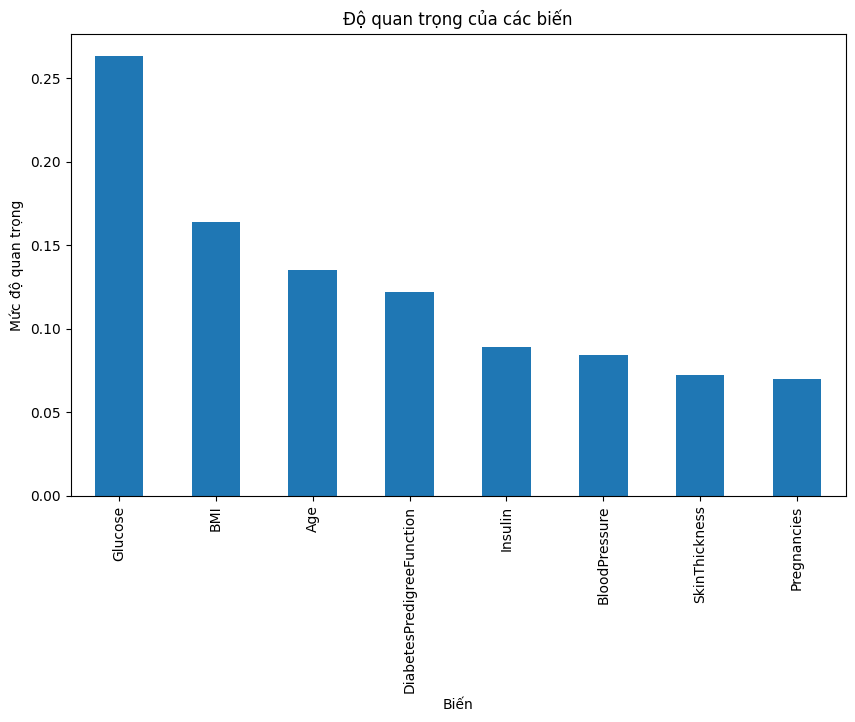

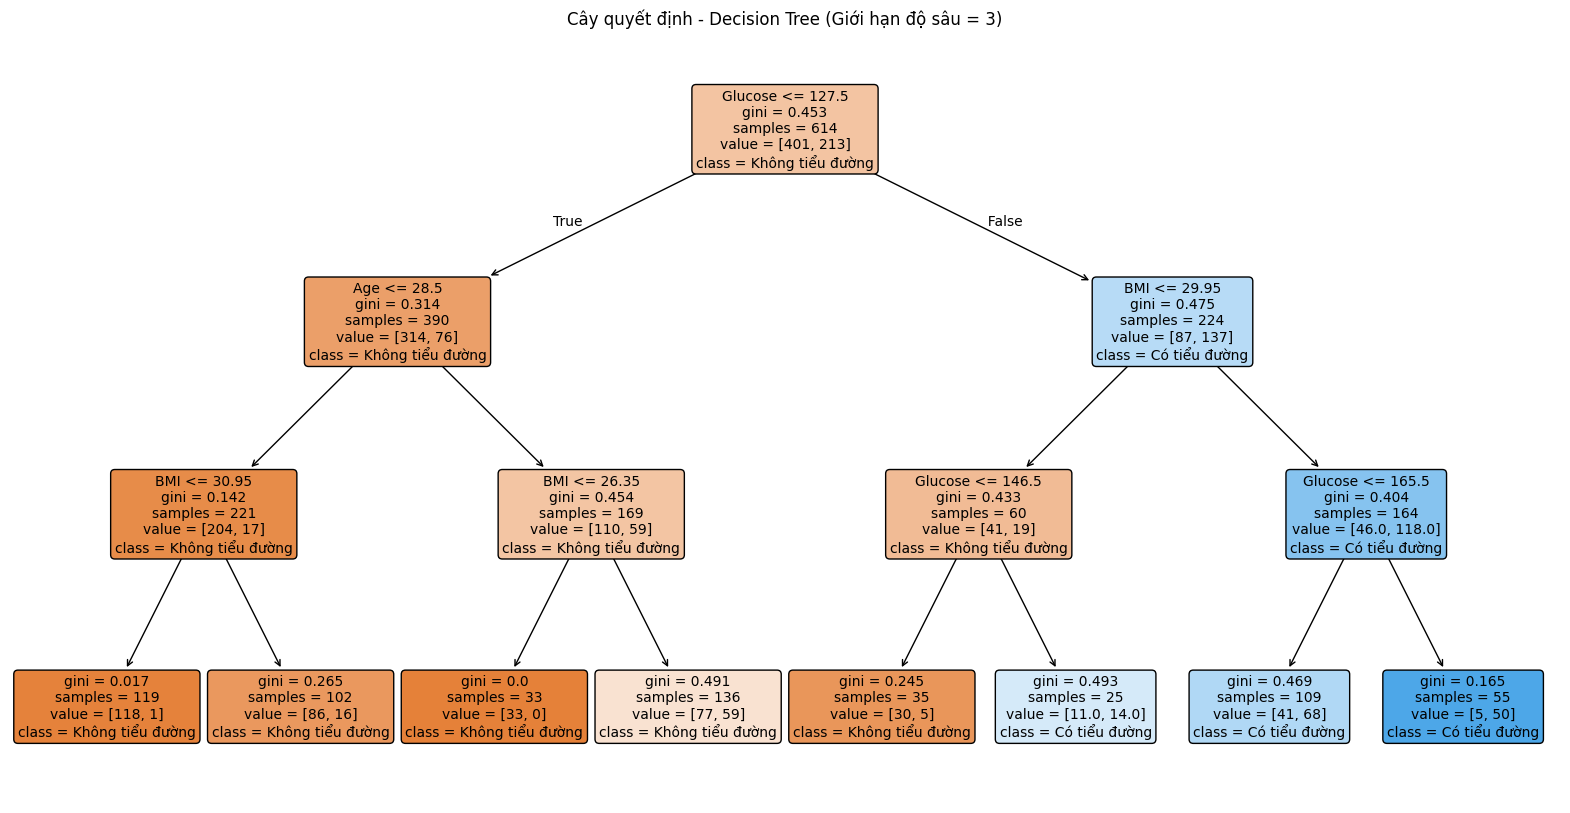

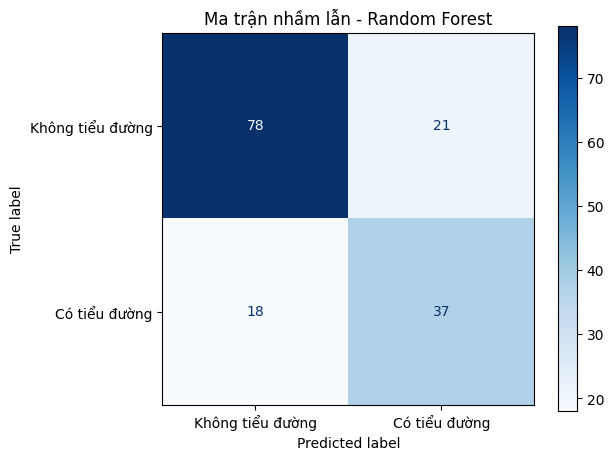

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
           'BMI', 'DiabetesPredigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)

df.head()

duplicate_rows = df[df.duplicated()]
print(f"Số dòng trùng lặp: {duplicate_rows.shape[0]}")

df = df.drop_duplicates()

print(df.dtypes)

print(df.info())

cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((df[cols_with_zero] == 0).sum())

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

print(df.isnull().sum())

col = 'Glucose'
print(f"Mean {col}: ", np.nanmean(df[col]))
print(f"Median {col}: ", np.nanmedian(df[col]))

mode_result = stats.mode(df[col], nan_policy='omit')
if np.ndim(mode_result.mode) == 0:
    mode_value = mode_result.mode
else:
    mode_value = mode_result.mode
print(f"Mode {col}: ", mode_value)

desc = df.describe()
print(desc)

for col in cols_with_zero:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(df.isnull().sum())

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print(" Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict (X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

import matplotlib.pyplot as plt

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importances.plot(kind='bar')
plt.title('Độ quan trọng của các biến')
plt.xlabel('Biến')
plt.ylabel('Mức độ quan trọng')
plt.show()

from sklearn import tree
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(20, 10))
tree.plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Không tiểu đường', 'Có tiểu đường'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Cây quyết định - Decision Tree (Giới hạn độ sâu = 3)")
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_rf = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Không tiểu đường', 'Có tiểu đường'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
plt.title("Ma trận nhầm lẫn - Random Forest")
plt.show()

